DATA

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()
print("Uploaded files:")
print(list(uploaded.keys()))

Saving spam.csv to spam.csv
Uploaded files:
['spam.csv']


DATA PRE PROCESSING

In [14]:
file_name = "spam.csv"
df = pd.read_csv(file_name, encoding="latin-1")
print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)
display(df.head())

Dataset loaded successfully!
Dataset Shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [15]:
print("COLUMN NAMES:")
print(df.columns.tolist())
print("\nDATASET INFORMATION:")
df.info()
print("\nDATASET SHAPE:")
print(df.shape)

COLUMN NAMES:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

DATASET INFORMATION:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB

DATASET SHAPE:
(5572, 5)


MISSING VALUE ANALYSIS

In [16]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

Duplicate rows:
403


In [17]:
print(df.columns.tolist())

['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


TEXT CLEANING

In [18]:
# Remove unnecessary columns
df = df[['v1', 'v2']].copy()
# Rename columns
df.columns = ['label', 'message']
print("Columns after cleaning:")
print(df.columns.tolist())
display(df.head())

Columns after cleaning:
['label', 'message']


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [19]:
print("Missing values before removal:")
print(df.isnull().sum())

Missing values before removal:
label      0
message    0
dtype: int64


In [20]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [21]:
before_missing = df.shape[0]
df = df.dropna()
after_missing = df.shape[0]
print("Rows before missing-value removal:", before_missing)
print("Rows after missing-value removal:", after_missing)
print("\nMissing values after removal:")
print(df.isnull().sum())

Rows before missing-value removal: 5572
Rows after missing-value removal: 5572

Missing values after removal:
label      0
message    0
dtype: int64


Spam and Ham Counts:
label
ham     4825
spam     747
Name: count, dtype: int64


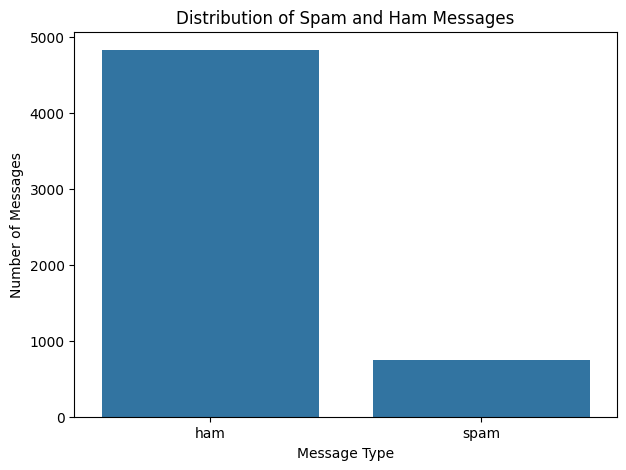

In [22]:
print("Spam and Ham Counts:")
print(df['label'].value_counts())

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='label')
plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.show()

In [39]:
import re
import string

def clean_text(text):
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_message'] = df['message'].apply(clean_text)

display(df[['message', 'clean_message']].head(10))

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling its been weeks now a...
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me t...
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request melle melle oru minnaminun...
8,WINNER!! As a valued network customer you have...,winner as a valued network customer you have b...
9,Had your mobile 11 months or more? U R entitle...,had your mobile months or more u r entitled to...


In [24]:
# Making a few numerical features from the messages
# These features will help us find unusual/long messages
df['char_count'] = df['clean_message'].apply(len)
df['word_count'] = df['clean_message'].apply(
    lambda message: len(message.split())
)
df['sentence_count'] = df['clean_message'].apply(
    lambda message: len(re.split(r'[.!?]+', message))
)
# Checking the new columns
print(df[['label', 'char_count', 'word_count', 'sentence_count']].head())

  label  char_count  word_count  sentence_count
0   ham         102          20               1
1   ham          23           6               1
2  spam         121          25               1
3   ham          43          11               1
4   ham          59          13               1


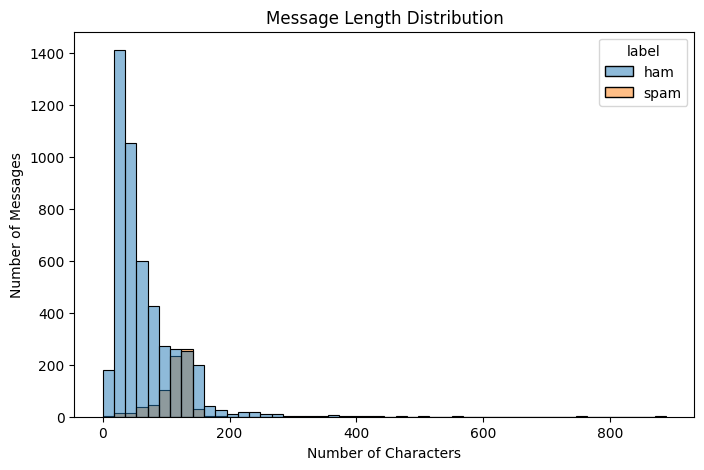

In [25]:
# Distribution of message length
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x='char_count',
    hue='label',
    bins=50
)
plt.title('Message Length Distribution')
plt.xlabel('Number of Characters')
plt.ylabel('Number of Messages')
plt.show()

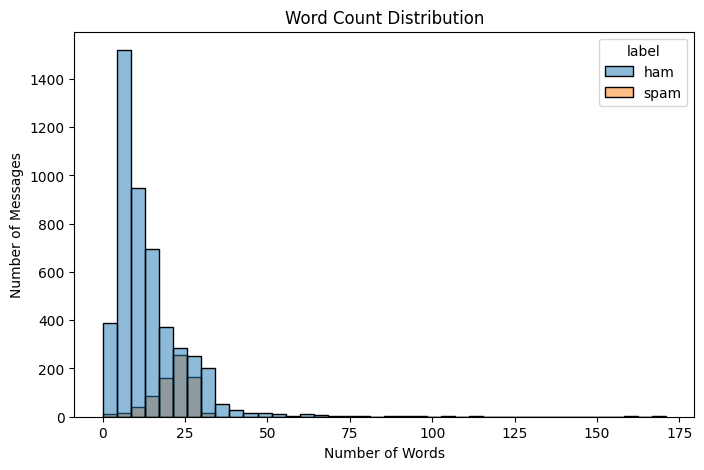

In [26]:
# Distribution of number of words
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x='word_count',
    hue='label',
    bins=40
)
plt.title('Word Count Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Number of Messages')
plt.show()

In [27]:
# Finding unusual values in our numerical columns
columns = ['char_count', 'word_count', 'sentence_count']
for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    print(col, "outliers:", count)

char_count outliers: 84
word_count outliers: 86
sentence_count outliers: 0


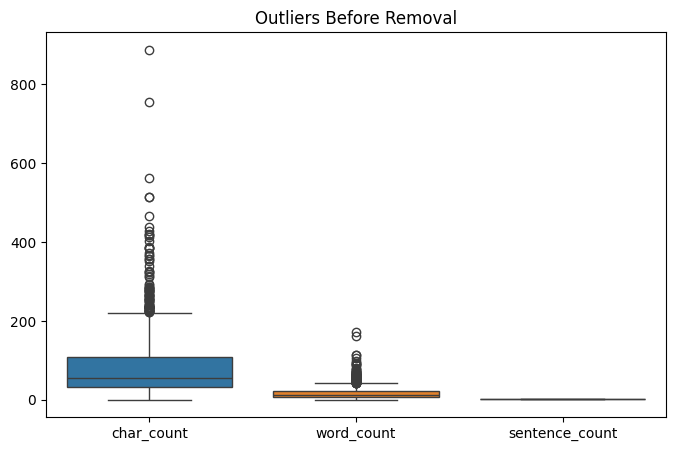

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[columns])
plt.title("Outliers Before Removal")
plt.show()

In [29]:
# Removing extreme values from the dataset
df_clean = df.copy()
for col in columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
    ]
print("Original rows:", len(df))
print("Rows after removing outliers:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 5572
Rows after removing outliers: 5482
Rows removed: 90


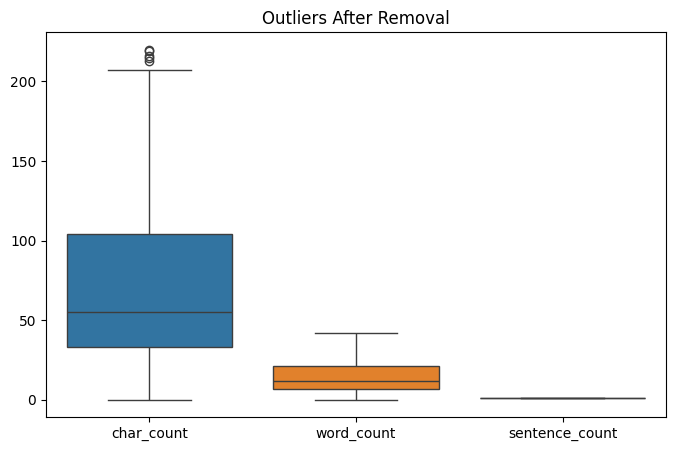

In [30]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean[columns])
plt.title("Outliers After Removal")
plt.show()

TF-IDF

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# ham = 0 and spam = 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
# Dividing data into training and testing
train_text, test_text, train_label, test_label = train_test_split(
    df['clean_message'],
    df['label_num'],
    test_size=0.2,
    random_state=42
)

# Converting text into numbers
tfidf = TfidfVectorizer()
train_data = tfidf.fit_transform(train_text)
test_data = tfidf.transform(test_text)
# Creating and training the model
model = LogisticRegression(max_iter=1000)
model.fit(train_data, train_label)
# Checking model predictions
result = model.predict(test_data)
print("Results before removing outliers")
print("Accuracy:", round(accuracy_score(test_label, result), 3))
print("Precision:", round(precision_score(test_label, result), 3))
print("Recall:", round(recall_score(test_label, result), 3))
print("F1 Score:", round(f1_score(test_label, result), 3))

Results before removing outliers
Accuracy: 0.964
Precision: 1.0
Recall: 0.733
F1 Score: 0.846


TRAIN/TEST SPLIT

In [32]:
# Making the labels numeric
df_clean['label_num'] = df_clean['label'].map({'ham': 0, 'spam': 1})
# Splitting the cleaned data
train_text, test_text, train_label, test_label = train_test_split(
    df_clean['clean_message'],
    df_clean['label_num'],
    test_size=0.2,
    random_state=42
)
# Converting messages into numbers
tfidf = TfidfVectorizer()
train_data = tfidf.fit_transform(train_text)
test_data = tfidf.transform(test_text)
# Training the model
model = LogisticRegression(max_iter=1000)
model.fit(train_data, train_label)
# Making predictions
result = model.predict(test_data)
print("Results after removing outliers")
print("Accuracy:", round(accuracy_score(test_label, result), 3))
print("Precision:", round(precision_score(test_label, result), 3))
print("Recall:", round(recall_score(test_label, result), 3))
print("F1 Score:", round(f1_score(test_label, result), 3))

Results after removing outliers
Accuracy: 0.959
Precision: 0.992
Recall: 0.735
F1 Score: 0.844


classification models

SVM

In [35]:
# SVM Classifier
svm_model = LinearSVC(random_state=42)
svm_model.fit(train_data, train_label)
svm_prediction = svm_model.predict(test_data)
print("SVM Results")
print("Accuracy :", accuracy_score(test_label, svm_prediction))
print("Precision:", precision_score(test_label, svm_prediction))
print("Recall   :", recall_score(test_label, svm_prediction))
print("F1 Score :", f1_score(test_label, svm_prediction))

SVM Results
Accuracy : 0.9808568824065633
Precision: 0.9738562091503268
Recall   : 0.8975903614457831
F1 Score : 0.9341692789968652


NAIVE BAYES

In [36]:
# Naive Bayes Classifier
nb_model = MultinomialNB()
nb_model.fit(train_data, train_label)
nb_prediction = nb_model.predict(test_data)
print("Naive Bayes Results")
print("Accuracy :", accuracy_score(test_label, nb_prediction))
print("Precision:", precision_score(test_label, nb_prediction))
print("Recall   :", recall_score(test_label, nb_prediction))
print("F1 Score :", f1_score(test_label, nb_prediction))

Naive Bayes Results
Accuracy : 0.9471285323609845
Precision: 1.0
Recall   : 0.6506024096385542
F1 Score : 0.7883211678832117


DECISION TREE

In [37]:
# Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(train_data, train_label)
dt_prediction = dt_model.predict(test_data)
print("Decision Tree Results")
print("Accuracy :", accuracy_score(test_label, dt_prediction))
print("Precision:", precision_score(test_label, dt_prediction))
print("Recall   :", recall_score(test_label, dt_prediction))
print("F1 Score :", f1_score(test_label, dt_prediction))

Decision Tree Results
Accuracy : 0.9480401093892434
Precision: 0.8343558282208589
Recall   : 0.8192771084337349
F1 Score : 0.8267477203647416


Model comparison

In [38]:
# Comparison of all classifiers
results = {
    'Model': ['SVM', 'Naive Bayes', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(test_label, svm_prediction),
        accuracy_score(test_label, nb_prediction),
        accuracy_score(test_label, dt_prediction)
    ],
    'Precision': [
        precision_score(test_label, svm_prediction),
        precision_score(test_label, nb_prediction),
        precision_score(test_label, dt_prediction)
    ],
    'Recall': [
        recall_score(test_label, svm_prediction),
        recall_score(test_label, nb_prediction),
        recall_score(test_label, dt_prediction)
    ],
    'F1 Score': [
        f1_score(test_label, svm_prediction),
        f1_score(test_label, nb_prediction),
        f1_score(test_label, dt_prediction)
    ]
}
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,SVM,0.980857,0.973856,0.897590,0.934169
1,Naive Bayes,0.947129,1.000000,0.650602,0.788321
2,Decision Tree,0.948040,0.834356,0.819277,0.826748
